# BƯỚC 5 – LÀM SẠCH DỮ LIỆU NÂNG CAO & PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

**Nguồn dữ liệu:** MongoDB Atlas – database `CGV_data`, collection `showtimes`.

Notebook này thực hiện đầy đủ các yêu cầu:
1. Kết nối bằng lập trình đến MongoDB Atlas và tải dữ liệu về Python.
2. Đánh giá và xử lý giá trị thiếu, **không xóa tùy tiện các dòng**.
3. Phân tích đơn biến (Univariate Analysis) cho biến số và biến phân loại.
4. Phát hiện ngoại lệ bằng IQR và trực quan hóa bằng Boxplot.
5. Phân tích đa biến (Multivariate Analysis).
6. Correlation Matrix + Heatmap.
7. Scatter plot.
8. Grouped Bar chart / Stacked Bar chart.
9. Grouped Boxplot.
10. Có phần **Before vs After** để kiểm tra ảnh hưởng của bước điền giá trị thiếu.

> **Lưu ý:** Không đưa mật khẩu MongoDB trực tiếp vào notebook. Khi chạy, notebook sẽ yêu cầu nhập URI bằng `getpass()` hoặc có thể lấy từ biến môi trường `MONGODB_URI`.


# SẢN PHẨM ĐẦU RA MONG ĐỢI (EXPECTED DELIVERABLES)

Notebook này được bổ sung để đáp ứng đúng 3 nhóm sản phẩm đầu ra trong yêu cầu: 

**1. Mã nguồn làm sạch & điền dữ liệu** – thể hiện rõ quá trình từ dữ liệu thô trong MongoDB thành Master Dataset sạch, có kiểm tra trước/sau xử lý.

**2. Hình ảnh trực quan hóa** – tối thiểu 5 biểu đồ chất lượng cao, có tiêu đề, nhãn trục X/Y và chú giải khi cần; bao gồm cả phân tích đơn biến và đa biến.

**3. Phân tích "So What?" (Insight)** – ngay bên dưới từng biểu đồ chuẩn đầu ra có một Markdown Cell giải thích biểu đồ thể hiện điều gì, ý nghĩa dữ liệu và tác động đến việc lựa chọn/thiết kế mô hình AI.

> **Lưu ý:** Các biểu đồ chuẩn đầu ra ở cuối notebook được tạo thành từng cell riêng để phần Insight nằm ngay bên dưới đúng yêu cầu.

## 0. Cài đặt thư viện

Nếu máy đã cài các thư viện thì có thể bỏ qua cell cài đặt.

```bash
pip install pymongo pandas numpy matplotlib scipy
```


In [26]:
# Nếu cần, chạy cell này một lần:
# %pip install pymongo pandas numpy matplotlib scipy


## 1. Import thư viện và thiết lập cấu hình

In [27]:
import os
import re
import getpass
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymongo import MongoClient
from scipy.stats import skew, kurtosis, gaussian_kde

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print("Thư viện đã sẵn sàng.")


Thư viện đã sẵn sàng.


## 2. Kết nối MongoDB Atlas và tải dữ liệu về Python

Database/collection theo cấu trúc đã dùng ở Bước 4:

- Database: `CGV_data`
- Collection: `showtimes`

Nếu đã có biến môi trường `MONGODB_URI`, notebook sẽ sử dụng biến đó. Nếu chưa có, notebook sẽ yêu cầu nhập URI.

**Không chia sẻ URI chứa mật khẩu lên GitHub hoặc gửi cho người khác.**


In [28]:
import os
import getpass
import certifi
from pymongo import MongoClient

# Nhập URI MongoDB Atlas một cách an toàn.
# Có thể đặt biến môi trường MONGODB_URI trước khi chạy notebook.
MONGODB_URI = os.getenv("MONGODB_URI")

if not MONGODB_URI:
    MONGODB_URI = getpass.getpass(
        "Nhập MongoDB Atlas URI (mongodb+srv://...): "
    )

DB_NAME = "CGV_data"
COLLECTION_NAME = "showtimes"

# Khởi tạo MongoClient với chứng chỉ certifi để tránh lỗi SSL handshake trên máy local
client = MongoClient(
    MONGODB_URI, 
    serverSelectionTimeoutMS=10000,
    tlsCAFile=certifi.where(),
    tlsAllowInvalidCertificates=True
)

# Kiểm tra kết nối
client.admin.command("ping")
collection = client[DB_NAME][COLLECTION_NAME]

print("Kết nối MongoDB Atlas thành công!")
print("Database :", DB_NAME)
print("Collection:", COLLECTION_NAME)
print("Số document:", collection.count_documents({}))

Kết nối MongoDB Atlas thành công!
Database : CGV_data
Collection: showtimes
Số document: 1172


In [29]:
# Tải toàn bộ document từ MongoDB về DataFrame
docs = list(collection.find({}))

df_raw = pd.DataFrame(docs)

# _id là khóa do MongoDB tạo tự động; không cần dùng trong EDA
if "_id" in df_raw.columns:
    df_raw = df_raw.drop(columns=["_id"])

print("Kích thước dữ liệu:", df_raw.shape)
display(df_raw.head())


Kích thước dữ liệu: (1172, 14)


,MovieName,Cinema,ShowDate,Format,ShowTime,GeneratedText,MovieURL,Rating,Director,Actors,Genre,ReleaseDate,Duration,Language
0,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,10:30,Tôi đã có cơ hội xem suất chiếu AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT tại r...,https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
1,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,16:00,"Hôm nay, tôi có cơ hội tham gia vào một trải nghiệm thú vị khi xem suất chiế...",https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
2,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,21:30,Tôi đã có cơ hội xem suất chiếu AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT tại r...,https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
3,CHIIKAWA: BÍ MẬT ĐẢO NGƯỜI CÁ,CGV Crescent Mall,2026-10-01,2D Phụ Đề Anh & Việt,18:00,"Hôm nay, tôi đã có cơ hội đến rạp chiếu CGV Crescent Mall để xem phim CHIIKA...",https://www.cgv.vn/default/chiikawa-the-movie.html,p,Kei Oikawa,"Haruka Aoki, Makoto Tanaka, Ari Ozawa, Yuka Iguchi, Takayuki Asai, Yuma Uchi...",Hoạt Hình,2026-08-28,99 phút,Tiếng Nhật với phụ đề Việt & Anh; Lồng tiếng Việt
4,HÒN ĐẢO QUÊN LÃNG,CGV Crescent Mall,2026-10-01,2D Lồng Tiếng Việt,19:40,"Tôi vừa có cơ hội xem suất chiếu ""HÒN ĐẢO QUÊN LÃNG"" tại rạp chiếu CGV Cresc...",https://www.cgv.vn/default/forgotten-island.html,K,Joel Crawford; Januel Mercado,"H.E.R., Liza Soberano, Dave Franco, Jenny Slate, Manny Jacinto, Dolly de Leo...","Hoạt Hình, Phiêu Lưu",2026-09-25,109 phút,Phụ đề Tiếng Việt & Lồng Tiếng Việt


## 3. Kiểm tra cấu trúc và kiểu dữ liệu ban đầu

In [30]:
print("Số dòng:", df_raw.shape[0])
print("Số cột :", df_raw.shape[1])
print("\nTên cột:")
print(df_raw.columns.tolist())

print("\nKiểu dữ liệu:")
display(df_raw.dtypes.to_frame("dtype"))

print("\n5 dòng đầu:")
display(df_raw.head())


Số dòng: 1172
Số cột : 14

Tên cột:
['MovieName', 'Cinema', 'ShowDate', 'Format', 'ShowTime', 'GeneratedText', 'MovieURL', 'Rating', 'Director', 'Actors', 'Genre', 'ReleaseDate', 'Duration', 'Language']

Kiểu dữ liệu:


,dtype
MovieName,str
Cinema,str
ShowDate,datetime64[us]
Format,str
ShowTime,str
GeneratedText,str
MovieURL,str
Rating,str
Director,str
Actors,str



5 dòng đầu:


,MovieName,Cinema,ShowDate,Format,ShowTime,GeneratedText,MovieURL,Rating,Director,Actors,Genre,ReleaseDate,Duration,Language
0,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,10:30,Tôi đã có cơ hội xem suất chiếu AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT tại r...,https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
1,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,16:00,"Hôm nay, tôi có cơ hội tham gia vào một trải nghiệm thú vị khi xem suất chiế...",https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
2,AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),CGV Crescent Mall,2026-10-01,2D Phụ Đề Việt | Rạp Lamour,21:30,Tôi đã có cơ hội xem suất chiếu AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT tại r...,https://www.cgv.vn/default/avengers-endgame-encore.html,T13,"Anthony Russo, Joe Russo","Robert Downey Jr., Chris Evans, Mark Ruffalo, Chris Hemsworth, Scarlett Joha...","Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",2026-09-25,183 phút,Tiếng Anh với phụ đề tiếng Việt
3,CHIIKAWA: BÍ MẬT ĐẢO NGƯỜI CÁ,CGV Crescent Mall,2026-10-01,2D Phụ Đề Anh & Việt,18:00,"Hôm nay, tôi đã có cơ hội đến rạp chiếu CGV Crescent Mall để xem phim CHIIKA...",https://www.cgv.vn/default/chiikawa-the-movie.html,p,Kei Oikawa,"Haruka Aoki, Makoto Tanaka, Ari Ozawa, Yuka Iguchi, Takayuki Asai, Yuma Uchi...",Hoạt Hình,2026-08-28,99 phút,Tiếng Nhật với phụ đề Việt & Anh; Lồng tiếng Việt
4,HÒN ĐẢO QUÊN LÃNG,CGV Crescent Mall,2026-10-01,2D Lồng Tiếng Việt,19:40,"Tôi vừa có cơ hội xem suất chiếu ""HÒN ĐẢO QUÊN LÃNG"" tại rạp chiếu CGV Cresc...",https://www.cgv.vn/default/forgotten-island.html,K,Joel Crawford; Januel Mercado,"H.E.R., Liza Soberano, Dave Franco, Jenny Slate, Manny Jacinto, Dolly de Leo...","Hoạt Hình, Phiêu Lưu",2026-09-25,109 phút,Phụ đề Tiếng Việt & Lồng Tiếng Việt


## 4. Chuẩn hóa kiểu dữ liệu

Một số trường trong dữ liệu CGV có bản chất khác nhau:

- `ShowDate`, `ReleaseDate`: ngày/thời gian.
- `Duration`: thời lượng phim, được tách số phút để có thể phân tích thống kê.
- Các trường còn lại chủ yếu là biến phân loại hoặc văn bản.

Bản sao `df_before` được giữ lại để so sánh **trước và sau khi xử lý thiếu**.


In [31]:
df_before = df_raw.copy()
df = df_raw.copy()

# Chuẩn hóa chuỗi: biến các chuỗi rỗng thành NaN
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)

# Parse ngày tháng
for col in ["ShowDate", "ReleaseDate"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Tách số phút từ Duration, ví dụ: "183 phút" -> 183
if "Duration" in df.columns:
    df["DurationMinutes"] = (
        df["Duration"]
        .astype("string")
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
        .astype(float)
    )

print("Các kiểu dữ liệu sau chuẩn hóa:")
display(df.dtypes.to_frame("dtype"))


Các kiểu dữ liệu sau chuẩn hóa:


,dtype
MovieName,str
Cinema,str
ShowDate,datetime64[us]
Format,str
ShowTime,str
GeneratedText,str
MovieURL,str
Rating,str
Director,str
Actors,str


# 5. XỬ LÝ GIÁ TRỊ THIẾU (HANDLING MISSING VALUES)

## 5.1. Đánh giá số lượng và tỷ lệ giá trị thiếu

Yêu cầu: thống kê `NaN / Null / None` cho từng cột.


In [32]:
missing_before = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(missing_before)


,Missing_Count,Missing_Percent
MovieName,0,0.0
Cinema,0,0.0
ShowDate,0,0.0
Format,0,0.0
ShowTime,0,0.0
GeneratedText,0,0.0
MovieURL,0,0.0
Rating,0,0.0
Director,0,0.0
Actors,0,0.0


In [33]:
# Trực quan hóa mẫu dữ liệu thiếu bằng matplotlib.
missing_plot = missing_before[missing_before["Missing_Count"] > 0]

if len(missing_plot) == 0:
    print("Không phát hiện giá trị thiếu trong dữ liệu.")
else:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_plot.index, missing_plot["Missing_Percent"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Tỷ lệ thiếu (%)")
    plt.title("Tỷ lệ giá trị thiếu theo cột")
    plt.tight_layout()
    plt.show()


Không phát hiện giá trị thiếu trong dữ liệu.


## 5.2. Chiến lược imputation

Không xóa dòng dữ liệu một cách tùy tiện.

- **Numerical:** điền bằng Median vì ít nhạy với ngoại lệ.
- **Categorical:** điền bằng Mode; nếu không có Mode thì dùng `Unknown`.
- **Datetime:** giữ nguyên nếu không đủ cơ sở suy luận; riêng cột thời gian có thể dùng nội suy thời gian nếu thật sự phù hợp.
- `DurationMinutes` là biến số được tạo từ `Duration`, nên dùng Median nếu thiếu.


In [34]:
# Lưu thống kê numerical trước imputation để so sánh
numeric_candidates = [
    c for c in ["DurationMinutes"] if c in df.columns
]

before_numeric_stats = (
    df[numeric_candidates]
    .describe()
    .T if numeric_candidates else pd.DataFrame()
)

# Numerical imputation bằng Median
for col in numeric_candidates:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: điền thiếu bằng Median = {median_value}")

# Categorical imputation bằng Mode / Unknown
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

for col in categorical_cols:
    mode_series = df[col].mode(dropna=True)
    fill_value = mode_series.iloc[0] if len(mode_series) > 0 else "Unknown"
    df[col] = df[col].fillna(fill_value)
    print(f"{col}: điền thiếu bằng Mode/Unknown = {fill_value}")

print("\nĐã hoàn tất imputation cho biến số và biến phân loại.")


DurationMinutes: điền thiếu bằng Median = 135.0
MovieName: điền thiếu bằng Mode/Unknown = TRẠI BUÔN NGƯỜI
Cinema: điền thiếu bằng Mode/Unknown = CGV Crescent Mall
Format: điền thiếu bằng Mode/Unknown = 2D Phụ Đề Anh
ShowTime: điền thiếu bằng Mode/Unknown = 19:00
GeneratedText: điền thiếu bằng Mode/Unknown = Hôm 02/10/2026, tôi đã có dịp được trải nghiệm suất chiếu phim "ÁN MẠNG KARAOKE" tại rạp chiếu CGV Crescent Mall. Vào lúc 14:50, tôi đã được ngồi vào ghế và bắt đầu tận hưởng bộ phim. Bộ phim được định dạng 2D Phụ Đề Anh, tạo nên một không khí riêng biệt và hấp dẫn. Qua trải nghiệm này, tôi đã cảm nhận được sự thú vị và hấp dẫn của bộ phim, khiến cho thời gian trôi qua nhanh chóng.
MovieURL: điền thiếu bằng Mode/Unknown = https://www.cgv.vn/default/trai-buon-nguoi.html
Rating: điền thiếu bằng Mode/Unknown = T18
Director: điền thiếu bằng Mode/Unknown = Toni Dương Bảo Anh
Actors: điền thiếu bằng Mode/Unknown = Steven Nguyễn, Quách Ngọc Ngoan, Tùng Mint, Huỳnh Minh Kiên,...
Genre: điền

### 5.3. Xử lý dữ liệu thời gian

Đối với `ShowDate` và `ReleaseDate`, không nên tự động điền một ngày bất kỳ vì ngày phát hành/lịch chiếu có ý nghĩa nghiệp vụ.

Notebook kiểm tra các giá trị thiếu trước. Nếu cần minh họa phương pháp time-series, phần dưới đây cho thấy cách dùng `ffill()` và `bfill()` trên một bản sao, **không thay đổi dữ liệu phân tích chính**.


In [35]:
date_cols = [c for c in ["ShowDate", "ReleaseDate"] if c in df.columns]

for col in date_cols:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} giá trị thiếu")

# Minh họa ffill/bfill trên bản sao, chỉ dùng khi nghiệp vụ cho phép.
df_time_demo = df[date_cols].copy()

if date_cols:
    df_time_demo_ffill = df_time_demo.ffill()
    df_time_demo_bfill = df_time_demo.bfill()
    print("\nĐã tạo 2 bản minh họa ffill và bfill.")
    print("Không dùng hai bản này để thay thế ngày gốc nếu không có căn cứ nghiệp vụ.")


ShowDate: 0 giá trị thiếu
ReleaseDate: 0 giá trị thiếu

Đã tạo 2 bản minh họa ffill và bfill.
Không dùng hai bản này để thay thế ngày gốc nếu không có căn cứ nghiệp vụ.


## 5.4. So sánh trước và sau khi điền giá trị thiếu

Mục tiêu: kiểm tra số lượng thiếu và thống kê phân phối của biến số trước/sau imputation.


,Before_Count,After_Count
Actors,0.0,0
Cinema,0.0,0
Director,0.0,0
Duration,0.0,0
DurationMinutes,NaN,0
Format,0.0,0
GeneratedText,0.0,0
Genre,0.0,0
Language,0.0,0
MovieName,0.0,0


,Statistic,Before,After
0,count,0.0,1172.000
1,mean,NaN,127.211
2,median,NaN,135.000
3,std,NaN,25.666
4,min,NaN,76.000
5,max,NaN,183.000


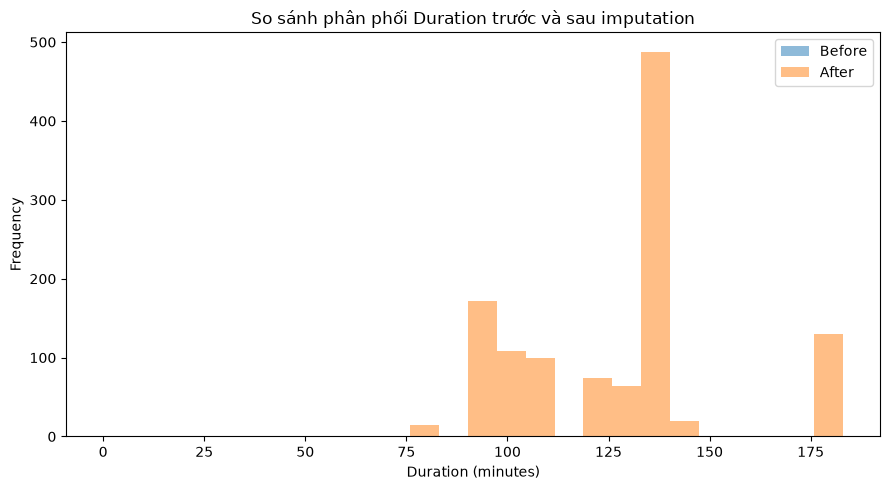

In [36]:
missing_after = pd.DataFrame({
    "Before_Count": df_before.isna().sum(),
    "After_Count": df.isna().sum()
})

display(missing_after)

# So sánh DurationMinutes nếu có
if "DurationMinutes" in df.columns:
    before = (
        df_before["DurationMinutes"]
        if "DurationMinutes" in df_before.columns
        else pd.Series(dtype=float)
    )
    after = df["DurationMinutes"]

    comparison = pd.DataFrame({
        "Statistic": ["count", "mean", "median", "std", "min", "max"],
        "Before": [
            before.count(),
            before.mean(),
            before.median(),
            before.std(),
            before.min(),
            before.max()
        ],
        "After": [
            after.count(),
            after.mean(),
            after.median(),
            after.std(),
            after.min(),
            after.max()
        ]
    })

    display(comparison.round(3))

    plt.figure(figsize=(9, 5))
    plt.hist(before.dropna(), bins=15, alpha=0.5, label="Before")
    plt.hist(after.dropna(), bins=15, alpha=0.5, label="After")
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Frequency")
    plt.title("So sánh phân phối Duration trước và sau imputation")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 6. PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE ANALYSIS)

## 6.1. Xác định biến số và biến phân loại

Các biến số được dùng cho thống kê gồm những biến có thể biểu diễn bằng số, nổi bật là `DurationMinutes`.

Các biến phân loại gồm `MovieName`, `Cinema`, `Format`, `ShowTime`, `Rating`, `Director`, `Genre`, `Language`, ...


In [37]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Chọn các categorical phù hợp để tránh phân tích quá nhiều trường văn bản dài
preferred_categorical = [
    "MovieName", "Cinema", "Format", "Rating", "Genre", "Language"
]
categorical_analysis_cols = [
    c for c in preferred_categorical if c in df.columns
]

print("Biến số:", numeric_cols)
print("Biến phân loại dùng trong EDA:", categorical_analysis_cols)


Biến số: ['DurationMinutes']
Biến phân loại dùng trong EDA: ['MovieName', 'Cinema', 'Format', 'Rating', 'Genre', 'Language']


## 6.2. Thống kê mô tả: Mean, Median, Std, Skewness, Kurtosis

In [38]:
if numeric_cols:
    rows = []
    for col in numeric_cols:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        rows.append({
            "Variable": col,
            "Mean": s.mean(),
            "Median": s.median(),
            "Std": s.std(),
            "Skewness": skew(s) if len(s) > 2 else np.nan,
            "Kurtosis": kurtosis(s) if len(s) > 3 else np.nan,
            "Min": s.min(),
            "Max": s.max()
        })

    univariate_numeric_stats = pd.DataFrame(rows)
    display(univariate_numeric_stats.round(3))
else:
    print("Không có biến số để phân tích.")


,Variable,Mean,Median,Std,Skewness,Kurtosis,Min,Max
0,DurationMinutes,127.211,135.0,25.666,0.629,0.188,76.0,183.0


## 6.3. Histogram + KDE

Yêu cầu: biểu đồ phân phối cho biến số, kèm đường cong ước lượng mật độ (KDE).


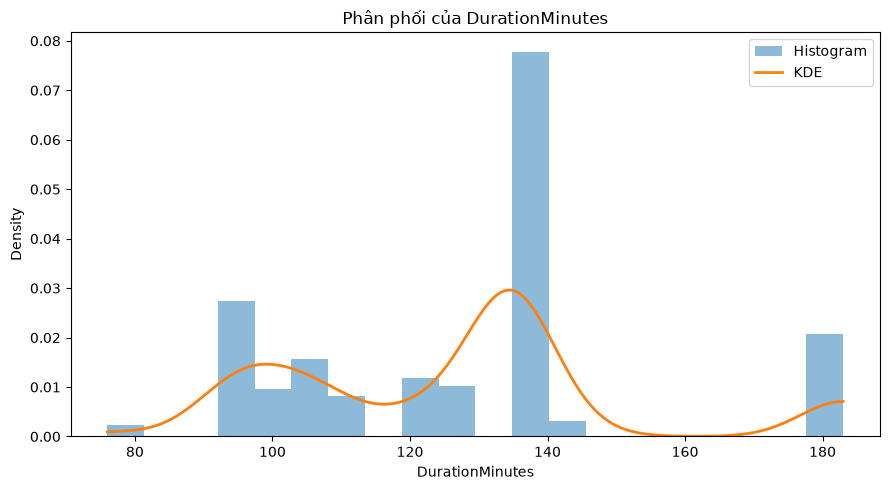

In [39]:
for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=20, density=True, alpha=0.5, label="Histogram")

    # KDE bằng scipy
    if values.nunique() > 1 and len(values) > 2:
        x = np.linspace(values.min(), values.max(), 300)
        kde = gaussian_kde(values)
        plt.plot(x, kde(x), linewidth=2, label="KDE")

    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(f"Phân phối của {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6.4. Phát hiện ngoại lệ bằng IQR

Quy tắc:

- Q1 = phân vị 25%
- Q3 = phân vị 75%
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR


In [40]:
iqr_results = []

for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (s < lower) | (s > upper)

    iqr_results.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(outlier_mask.sum()),
        "Outlier_Percent": round(outlier_mask.mean() * 100, 2)
    })

iqr_table = pd.DataFrame(iqr_results)
display(iqr_table.round(3))


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,DurationMinutes,103.0,135.0,32.0,55.0,183.0,0,0.0


## 6.5. Boxplot cho biến số

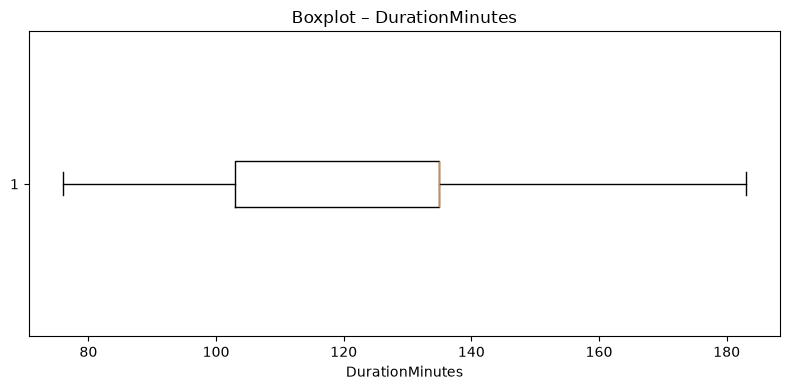

In [41]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(pd.to_numeric(df[col], errors="coerce").dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot – {col}")
    plt.tight_layout()
    plt.show()


## 6.6. Tần số và tỷ lệ phần trăm cho biến phân loại

Với biến phân loại, tính số lần xuất hiện và tỷ lệ phần trăm của từng danh mục.


In [42]:
categorical_frequency = {}

for col in categorical_analysis_cols:
    freq = df[col].value_counts(dropna=False)
    pct = (df[col].value_counts(normalize=True, dropna=False) * 100)

    table = pd.DataFrame({
        "Frequency": freq,
        "Percent": pct.round(2)
    })

    categorical_frequency[col] = table
    print(f"\n===== {col} =====")
    display(table.head(20))



===== MovieName =====


,Frequency,Percent
MovieName,,
TRẠI BUÔN NGƯỜI,488,41.64
AVENGERS: HỒI KẾT - PHIÊN BẢN ĐẶC BIỆT (CHIẾU LẠI),130,11.09
VÙNG ĐẤT QUỶ DỮ,110,9.39
LÊN HƯƠNG,74,6.31
LAPUTA: LÂU ĐÀI TRÊN KHÔNG,64,5.46
ÁN MẠNG KARAOKE,60,5.12
TRÁI TIM QUÁI THÚ,54,4.61
HÒN ĐẢO QUÊN LÃNG,51,4.35
MARNIE YÊU DẤU,49,4.18



===== Cinema =====


,Frequency,Percent
Cinema,,
CGV Crescent Mall,297,25.34
CGV Hùng Vương Plaza,297,25.34
CGV Vivo City,272,23.21
CGV Thảo Điền Pearl,215,18.34
CGV Vincom Thủ Đức,91,7.76



===== Format =====


...

,Frequency,Percent
Rating,,
T18,647,55.20
T13,184,15.70
K,184,15.70
T16,136,11.60
p,21,1.79



===== Genre =====


,Frequency,Percent
Genre,,
"Hành Động, Hồi hộp",488,41.64
Hoạt Hình,134,11.43
"Hành Động, Khoa Học Viễn Tưởng, Phiêu Lưu",130,11.09
"Hành Động, Kinh Dị",110,9.39
"Gia đình, Tâm Lý",74,6.31
"Hài, Hồi hộp",60,5.12
Hành Động,54,4.61
"Hoạt Hình, Phiêu Lưu",51,4.35
Kinh Dị,49,4.18



===== Language =====


,Frequency,Percent
Language,,
Tiếng Việt,624,53.24
Tiếng Anh - Phụ đề Tiếng Việt,164,13.99
Tiếng Anh với phụ đề tiếng Việt,130,11.09
Tiếng Nhật - Phụ đề Tiếng Việt; Lồng Tiếng Việt,113,9.64
Phụ đề Tiếng Việt & Lồng Tiếng Việt,51,4.35
Vietnamese,49,4.18
Tiếng Trung Quốc - Phụ đề Tiếng Việt,20,1.71
Phụ đề tiếng Việt & tiếng Anh,15,1.28
Tiếng Nhật với phụ đề Việt & Anh; Lồng tiếng Việt,6,0.51


## 6.7. Bar chart cho biến phân loại

Để biểu đồ dễ đọc, hiển thị **Top 10** danh mục có tần số cao nhất.


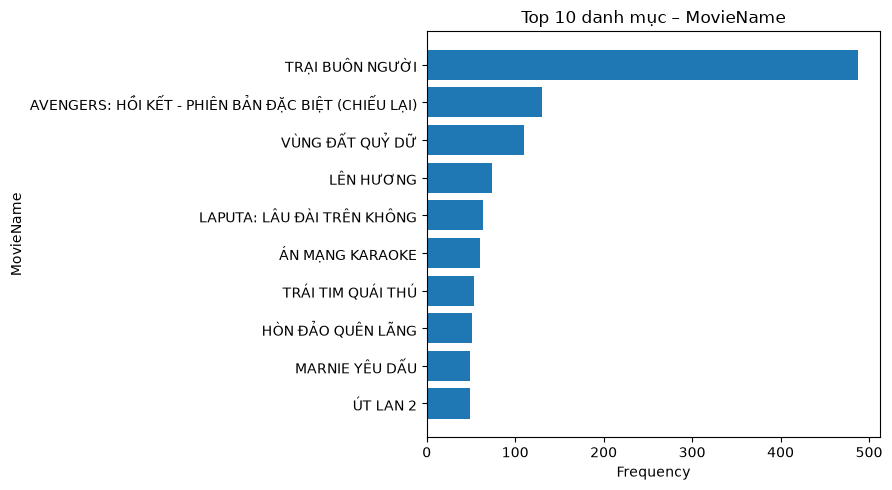

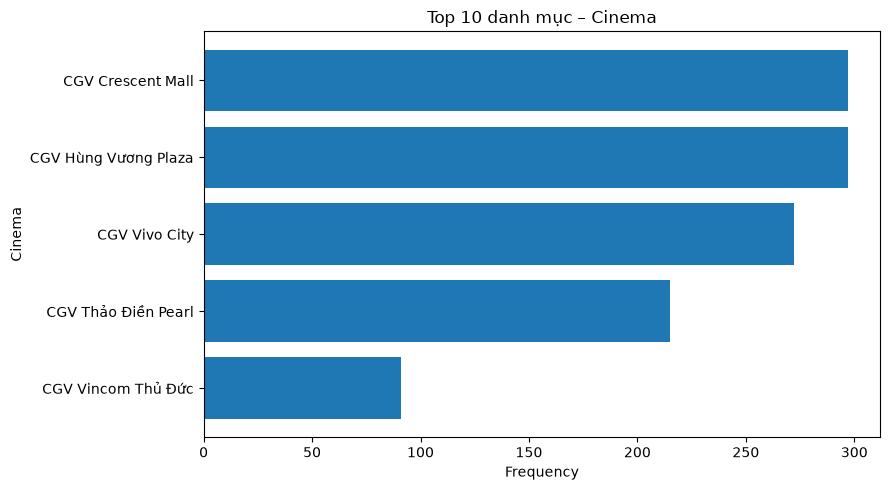

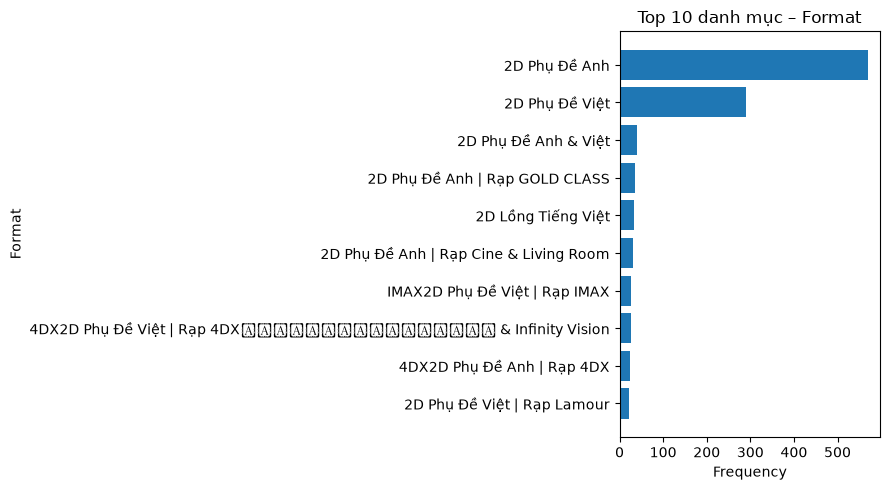

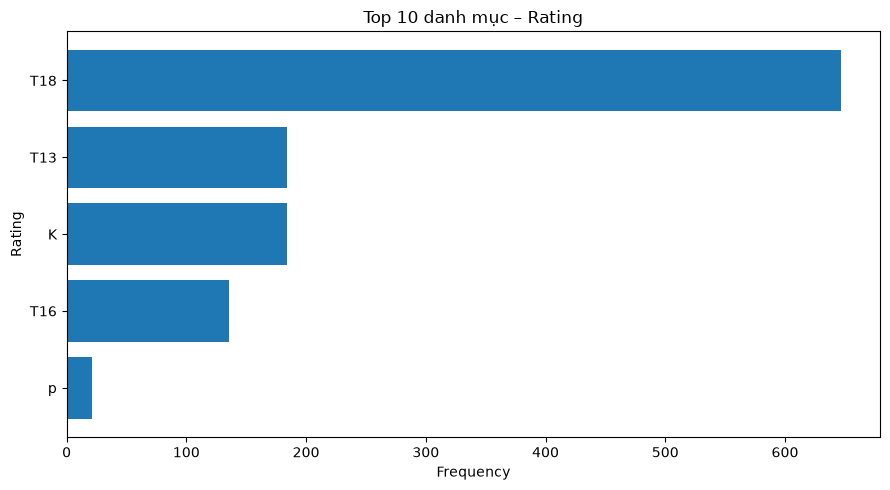

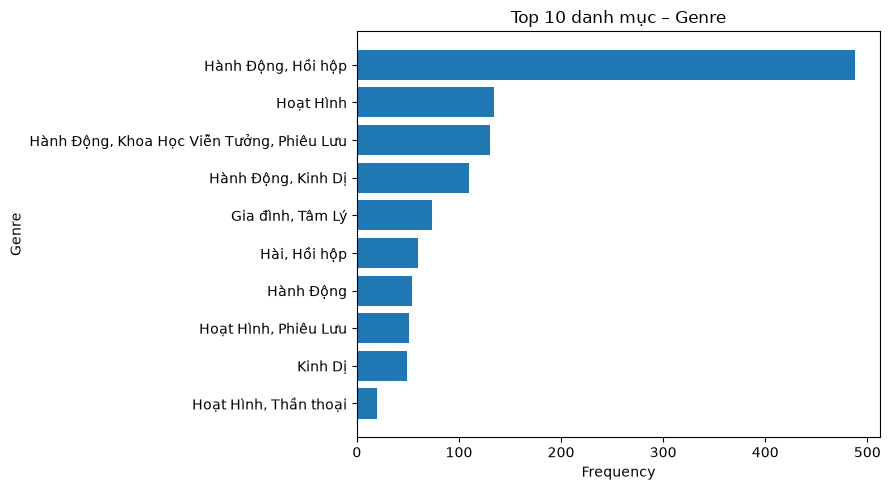

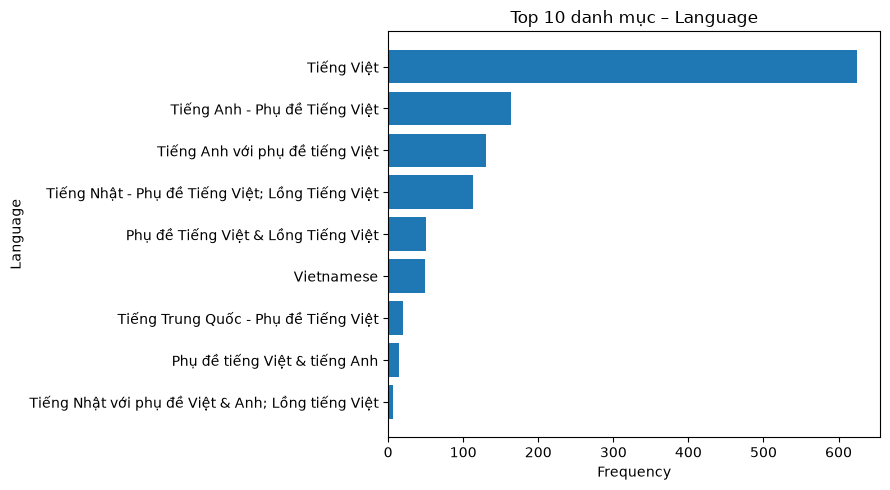

In [43]:
for col in categorical_analysis_cols:
    counts = df[col].value_counts().head(10).sort_values()

    plt.figure(figsize=(9, 5))
    plt.barh(counts.index.astype(str), counts.values)
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.title(f"Top 10 danh mục – {col}")
    plt.tight_layout()
    plt.show()


# 7. PHÂN TÍCH ĐA BIẾN (MULTIVARIATE ANALYSIS)

## 7.1. Biến số vs. biến số – Correlation Matrix

Sử dụng hệ số tương quan Pearson cho các biến số. Nếu chỉ có một biến số, notebook sẽ thông báo rằng chưa đủ biến số để tạo ma trận tương quan có ý nghĩa.


In [44]:
corr_cols = numeric_cols.copy()

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(method="pearson")
    display(corr.round(3))
else:
    corr = pd.DataFrame()
    print("Chưa có ít nhất 2 biến số để tính Correlation Matrix.")


Chưa có ít nhất 2 biến số để tính Correlation Matrix.


## 7.2. Heatmap ma trận tương quan

In [45]:
if len(corr_cols) >= 2:
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, interpolation="nearest", aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)

    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha="center", va="center")

    plt.title("Correlation Matrix – Pearson")
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ biến số để vẽ Heatmap.")


Không đủ biến số để vẽ Heatmap.


## 7.3. Phân tích xu hướng giữa các biến liên tục – Scatter plot

Notebook tạo scatter plot cho các cặp biến số nếu có ít nhất 2 biến số.


In [46]:
if len(numeric_cols) >= 2:
    x_col, y_col = numeric_cols[0], numeric_cols[1]

    plt.figure(figsize=(8, 5))
    plt.scatter(df[x_col], df[y_col], alpha=0.6)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter plot: {x_col} vs {y_col}")
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có đủ 2 biến số để vẽ Scatter plot.")


Chưa có đủ 2 biến số để vẽ Scatter plot.


## 7.4. Biến phân loại vs. biến số

Ví dụ: so sánh **thời lượng phim trung bình theo rạp chiếu**.

Nếu dataset có `Cinema` và `DurationMinutes`, notebook sẽ tính Mean/Median/Count và vẽ Grouped Bar chart.


Thống kê DurationMinutes theo Cinema:


,mean,median,count
Cinema,,,
CGV Vivo City,131.67,135.0,272
CGV Hùng Vương Plaza,131.45,135.0,297
CGV Vincom Thủ Đức,124.79,135.0,91
CGV Crescent Mall,123.46,129.0,297
CGV Thảo Điền Pearl,121.93,121.0,215


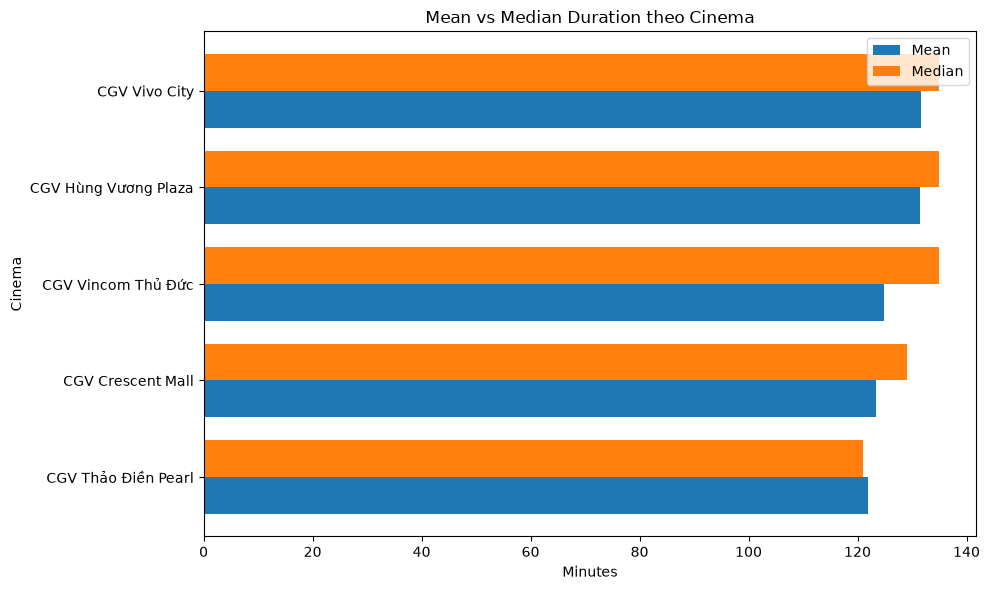

In [47]:
if "Cinema" in df.columns and "DurationMinutes" in df.columns:
    cinema_stats = (
        df.groupby("Cinema")["DurationMinutes"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    print("Thống kê DurationMinutes theo Cinema:")
    display(cinema_stats.round(2).head(20))

    top_cinemas = cinema_stats.head(10).index
    plot_data = cinema_stats.loc[top_cinemas].sort_values("mean")

    x = np.arange(len(plot_data))
    width = 0.38

    plt.figure(figsize=(10, 6))
    plt.barh(x - width/2, plot_data["mean"], height=width, label="Mean")
    plt.barh(x + width/2, plot_data["median"], height=width, label="Median")
    plt.yticks(x, plot_data.index.astype(str))
    plt.xlabel("Minutes")
    plt.ylabel("Cinema")
    plt.title("Mean vs Median Duration theo Cinema")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Thiếu Cinema hoặc DurationMinutes để phân tích.")


## 7.5. Biến phân loại vs. biến phân loại – Contingency Table

Sử dụng bảng chéo để quan sát phân phối tần số giữa hai thuộc tính phân loại.

Ví dụ: `Cinema × Format`.


Bảng chéo Cinema × Format:


Format,2D Lồng Tiếng Việt,2D Phụ Đề Anh,2D Phụ Đề Anh & Việt,2D Phụ Đề Anh | Rạp Cine & Living Room,2D Phụ Đề Anh | Rạp GOLD CLASS,2D Phụ Đề Anh | Rạp Lamour,2D Phụ Đề Anh | Rạp STARIUM,2D Phụ Đề Việt,2D Phụ Đề Việt\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t | Rạp Infinity Vision,2D Phụ Đề Việt | Rạp Cine & Living Room,2D Phụ Đề Việt | Rạp Lamour,2D Phụ Đề Việt | Rạp STARIUM,2D Phụ Đề Việt | Rạp STARIUM\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t & Infinity Vision,4DX2D Lồng Tiếng Việt | Rạp 4DX,4DX2D Phụ Đề Anh | Rạp 4DX,4DX2D Phụ Đề Việt | Rạp 4DX,4DX2D Phụ Đề Việt | Rạp 4DX\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t & Infinity Vision,IMAX2D Phụ Đề Việt | Rạp IMAX,SCREENX-2D Phụ Đề Việt | Rạp SCREENX,SCREENX-2D Phụ Đề Việt | Rạp SCREENX\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t & Infinity Vision
Cinema,,,,,,,,,,,,,,,,,,,,
CGV Crescent Mall,18,151,6,32,0,6,0,61,0,1,22,0,0,0,0,0,0,0,0,0
CGV Hùng Vương Plaza,1,154,0,0,35,0,0,45,0,0,0,0,0,6,12,0,13,0,12,19
CGV Thảo Điền Pearl,6,74,22,0,0,0,0,113,0,0,0,0,0,0,0,0,0,0,0,0
CGV Vincom Thủ Đức,8,59,0,0,0,0,7,13,0,0,0,2,2,0,0,0,0,0,0,0
CGV Vivo City,0,131,13,0,0,0,0,57,11,0,0,0,0,6,12,2,13,27,0,0


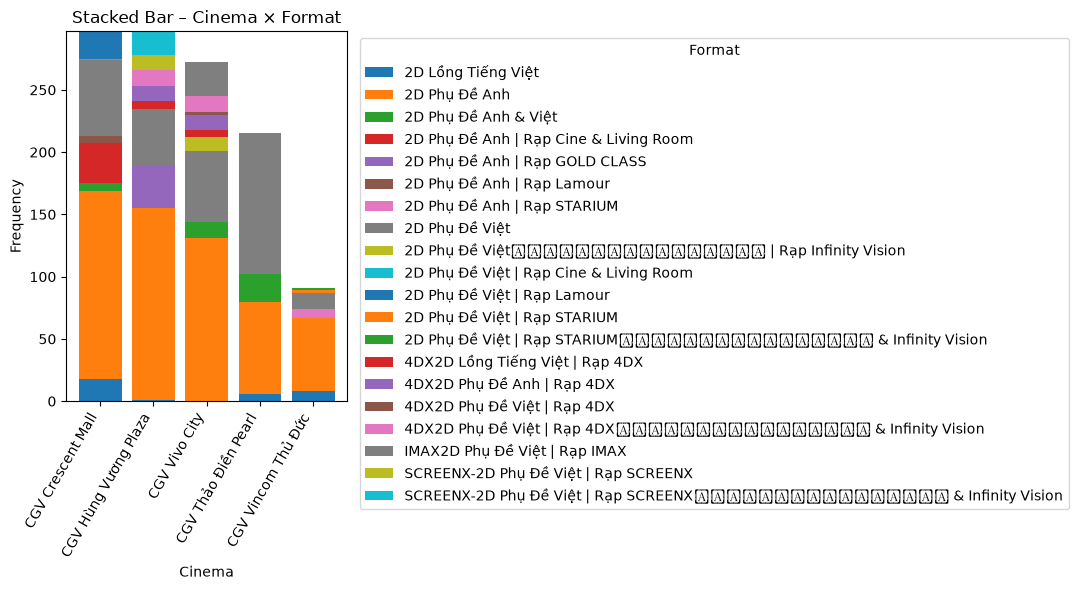

In [48]:
if "Cinema" in df.columns and "Format" in df.columns:
    crosstab = pd.crosstab(df["Cinema"], df["Format"])

    print("Bảng chéo Cinema × Format:")
    display(crosstab)

    # Vẽ Top 10 rạp theo tổng số suất chiếu
    top_rows = crosstab.sum(axis=1).sort_values(ascending=False).head(10).index
    plot_ct = crosstab.loc[top_rows]

    plt.figure(figsize=(11, 6))
    bottom = np.zeros(len(plot_ct))

    for category in plot_ct.columns:
        values = plot_ct[category].values
        plt.bar(plot_ct.index.astype(str), values, bottom=bottom, label=str(category))
        bottom += values

    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Frequency")
    plt.xlabel("Cinema")
    plt.title("Stacked Bar – Cinema × Format")
    plt.legend(title="Format", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Thiếu Cinema hoặc Format để tạo bảng chéo.")


## 7.6. Grouped Bar chart cho biến phân loại

Ví dụ: số suất chiếu theo `Format` trong từng rạp.

Biểu đồ này đáp ứng yêu cầu **Grouped Bar charts hoặc Stacked Bar charts**.


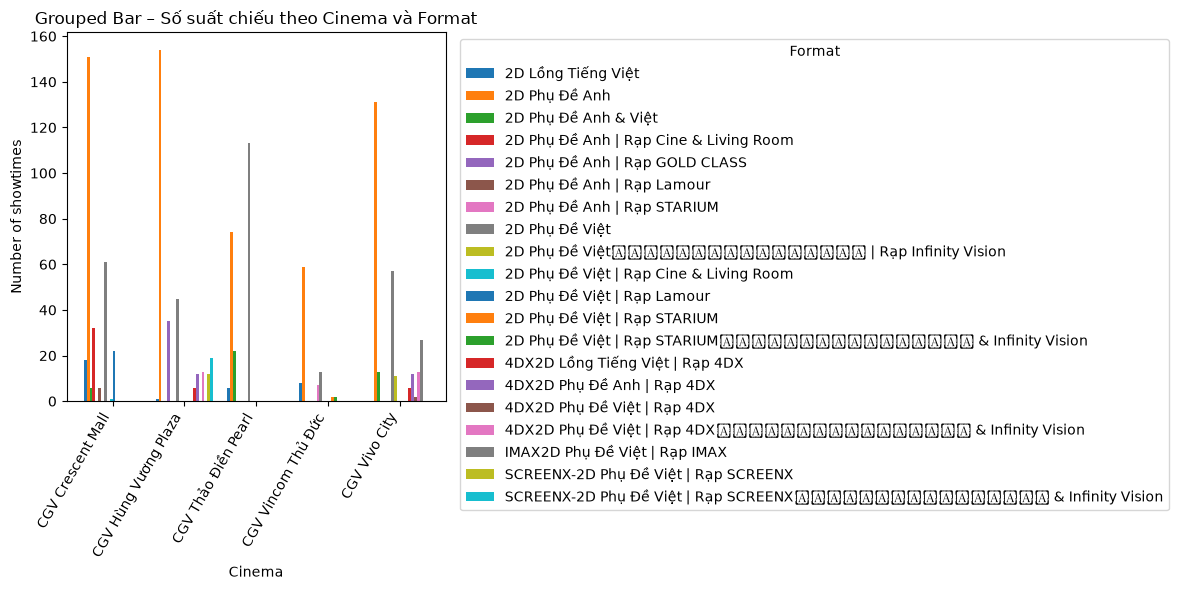

In [49]:
if "Cinema" in df.columns and "Format" in df.columns:
    top_cinemas = df["Cinema"].value_counts().head(8).index
    group_data = (
        df[df["Cinema"].isin(top_cinemas)]
        .groupby(["Cinema", "Format"])
        .size()
        .unstack(fill_value=0)
    )

    x = np.arange(len(group_data))
    formats = group_data.columns
    width = 0.8 / max(len(formats), 1)

    plt.figure(figsize=(12, 6))

    for i, fmt in enumerate(formats):
        plt.bar(
            x + (i - (len(formats)-1)/2) * width,
            group_data[fmt],
            width=width,
            label=str(fmt)
        )

    plt.xticks(x, group_data.index.astype(str), rotation=60, ha="right")
    plt.xlabel("Cinema")
    plt.ylabel("Number of showtimes")
    plt.title("Grouped Bar – Số suất chiếu theo Cinema và Format")
    plt.legend(title="Format", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Thiếu Cinema hoặc Format để vẽ Grouped Bar.")


## 7.7. Grouped Boxplot

So sánh phân phối `DurationMinutes` giữa các lớp phân loại `Rating`.

Đây là ví dụ trực tiếp cho yêu cầu **Grouped Box plots**.


In [59]:
if "Rating" in df.columns and "DurationMinutes" in df.columns:
    temp = df[["Rating", "DurationMinutes"]].copy()
    temp["DurationMinutes"] = pd.to_numeric(temp["DurationMinutes"], errors="coerce")
    temp = temp.dropna()

    # Chọn top rating có nhiều dữ liệu nhất
    top_ratings = temp["Rating"].astype(str).value_counts().head(10).index

    groups = []
    labels = []

    for r in top_ratings:
        vals = temp.loc[temp["Rating"].astype(str) == r, "DurationMinutes"].values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(str(r))

    if groups:
        plt.figure(figsize=(10, 6))
        plt.boxplot(groups, labels=labels, showfliers=True)
        plt.xlabel("Rating")
        plt.ylabel("Duration (minutes)")
        plt.title("Grouped Boxplot – Duration theo Rating")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print("Không đủ dữ liệu để vẽ Grouped Boxplot.")
else:
    print("Thiếu Rating hoặc DurationMinutes.")

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 1000x600 with 0 Axes>

# 8. TÓM TẮT KẾT QUẢ EDA

Cell dưới đây tạo một báo cáo ngắn tự động để hỗ trợ viết phần nhận xét trong báo cáo.


In [52]:
print("========== TÓM TẮT EDA ==========")
print(f"Số dòng sau khi tải từ MongoDB: {len(df_raw):,}")
print(f"Số cột phân tích: {df.shape[1]}")
print(f"Tổng số ô thiếu trước xử lý: {int(df_before.isna().sum().sum()):,}")
print(f"Tổng số ô thiếu sau xử lý: {int(df.isna().sum().sum()):,}")

if numeric_cols:
    for col in numeric_cols:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        print(
            f"- {col}: mean={s.mean():.2f}, median={s.median():.2f}, "
            f"std={s.std():.2f}"
        )

if "DurationMinutes" in df.columns:
    print(
        f"- DurationMinutes: min={df['DurationMinutes'].min():.0f}, "
        f"max={df['DurationMinutes'].max():.0f}"
    )

if "Cinema" in df.columns:
    print("- Cinema phổ biến nhất:", df["Cinema"].value_counts().idxmax())

if "Format" in df.columns:
    print("- Format phổ biến nhất:", df["Format"].value_counts().idxmax())

print("\nEDA đã hoàn tất.")


========== TÓM TẮT EDA ==========
Số dòng sau khi tải từ MongoDB: 1,172
Số cột phân tích: 15
Tổng số ô thiếu trước xử lý: 0
Tổng số ô thiếu sau xử lý: 0
- DurationMinutes: mean=127.21, median=135.00, std=25.67
- DurationMinutes: min=76, max=183
- Cinema phổ biến nhất: CGV Crescent Mall
- Format phổ biến nhất: 2D Phụ Đề Anh

EDA đã hoàn tất.


# 9. Xuất dữ liệu sau làm sạch

Lưu DataFrame sau xử lý thành CSV để có thể sử dụng cho các bước tiếp theo.

**Lưu ý:** bản này là dữ liệu đã imputation; dữ liệu gốc từ MongoDB vẫn được giữ trong `df_raw`.


In [53]:
OUTPUT_FILE = "cgv_eda_cleaned.csv"

df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print(f"Đã lưu: {OUTPUT_FILE}")
print("Kích thước:", df.shape)


Đã lưu: cgv_eda_cleaned.csv
Kích thước: (1172, 15)


# 10. Checklist đối chiếu yêu cầu đề bài

| Yêu cầu | Đã thực hiện |
|---|---|
| Kết nối bằng lập trình đến CSDL | ✅ MongoDB Atlas + PyMongo |
| Tải dữ liệu trở lại Python | ✅ `collection.find()` → DataFrame |
| Đánh giá số lượng và tỷ lệ thiếu | ✅ |
| Numerical imputation | ✅ Median |
| Categorical imputation | ✅ Mode / Unknown |
| Time-series methods | ✅ Minh họa `ffill()` / `bfill()` |
| So sánh trước và sau | ✅ |
| Mean / Median / Std | ✅ |
| Skewness / Kurtosis | ✅ |
| Histogram + KDE | ✅ |
| Phát hiện outlier bằng IQR | ✅ |
| Boxplot | ✅ |
| Tần số và tỷ lệ biến phân loại | ✅ |
| Bar chart | ✅ |
| Correlation Matrix | ✅ |
| Heatmap | ✅ |
| Scatter plot | ✅ |
| Contingency table | ✅ |
| Grouped/Stacked Bar | ✅ |
| Grouped Boxplot | ✅ |

## Kết luận

Notebook này thực hiện toàn bộ quy trình EDA theo cấu trúc yêu cầu của đề bài và sử dụng trực tiếp dữ liệu đã được nạp vào MongoDB Atlas ở Bước 4.



# 11. BỘ BIỂU ĐỒ CHUẨN ĐẦU RA & PHÂN TÍCH "SO WHAT?"

Phần này là **bộ deliverables chính thức** của Step 5. Có 6 biểu đồ, vượt yêu cầu tối thiểu 5 biểu đồ. Mỗi biểu đồ có một Markdown Cell Insight ngay bên dưới.

## Biểu đồ 1 – Histogram + KDE: Phân phối thời lượng phim

Mục tiêu: phân tích hình dạng phân phối, xu hướng tập trung và khả năng lệch/phân tán của `DurationMinutes`.

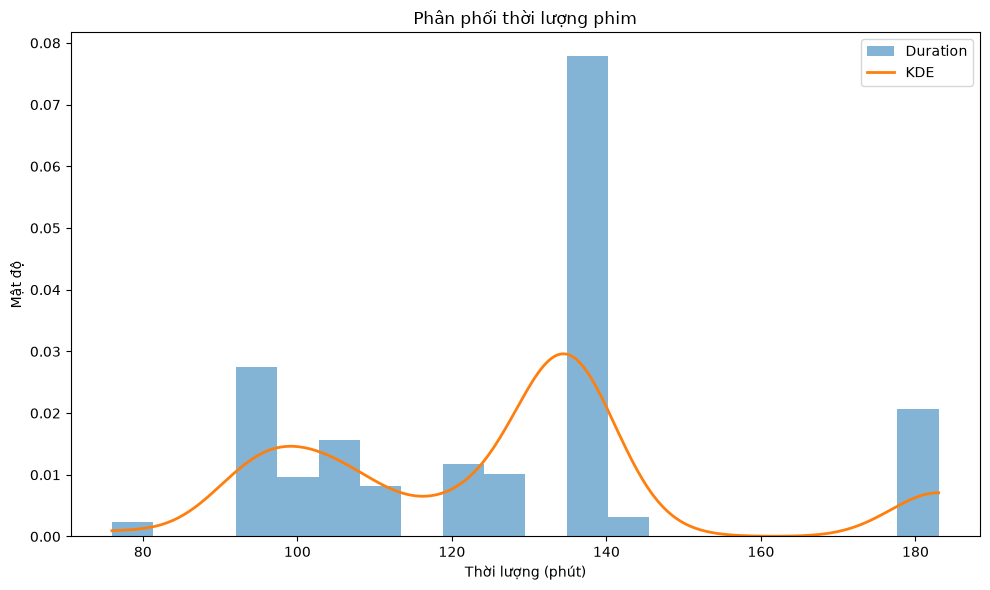

In [54]:
if 'DurationMinutes' in df.columns:
    values = pd.to_numeric(df['DurationMinutes'], errors='coerce').dropna()
    plt.figure(figsize=(10,6))
    plt.hist(values, bins=20, density=True, alpha=0.55, label='Duration')
    if len(values) >= 2 and values.nunique() > 1:
        from scipy.stats import gaussian_kde
        x = np.linspace(values.min(), values.max(), 300)
        kde = gaussian_kde(values)
        plt.plot(x, kde(x), linewidth=2, label='KDE')
    plt.title('Phân phối thời lượng phim')
    plt.xlabel('Thời lượng (phút)')
    plt.ylabel('Mật độ')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Không tìm thấy cột DurationMinutes.')


### 💡 So What?

Biểu đồ cho biết thời lượng phim tập trung ở khoảng nào và hình dạng phân phối có cân đối hay lệch. Nếu phân phối lệch hoặc có các giá trị cực đoan, **median** thường là lựa chọn ổn định hơn mean khi điền thiếu cho biến thời lượng. Đối với mô hình AI, `DurationMinutes` có thể được sử dụng như một numerical feature; cần kiểm tra phân phối và outlier trước khi đưa vào các mô hình nhạy với thang đo hoặc giá trị cực đoan.

## Biểu đồ 2 – Boxplot: Phát hiện ngoại lệ của thời lượng phim

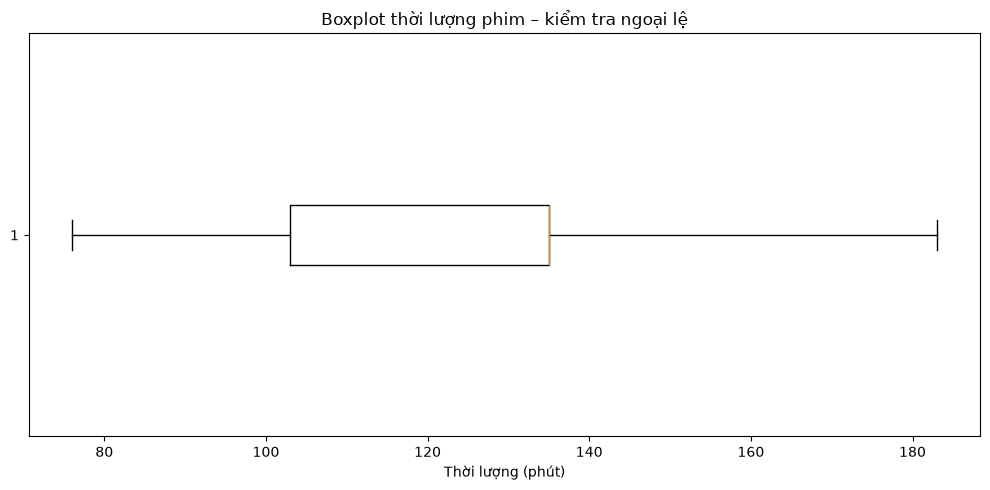

In [55]:
if 'DurationMinutes' in df.columns:
    values = pd.to_numeric(df['DurationMinutes'], errors='coerce').dropna()
    plt.figure(figsize=(10,5))
    plt.boxplot(values, vert=False)
    plt.title('Boxplot thời lượng phim – kiểm tra ngoại lệ')
    plt.xlabel('Thời lượng (phút)')
    plt.tight_layout()
    plt.show()
else:
    print('Không tìm thấy cột DurationMinutes.')


### 💡 So What?

Boxplot cho thấy median, khoảng tứ phân vị và các quan sát có thể là outlier của `DurationMinutes`. Một điểm nằm ngoài whisker không tự động có nghĩa là dữ liệu sai; cần đối chiếu với nghiệp vụ phim trước khi loại bỏ. Khi xây dựng mô hình AI, kết quả IQR giúp quyết định có cần xử lý outlier hoặc dùng các phương pháp/mô hình ít nhạy với outlier hay không.

## Biểu đồ 3 – Bar chart: Top 10 thể loại phim

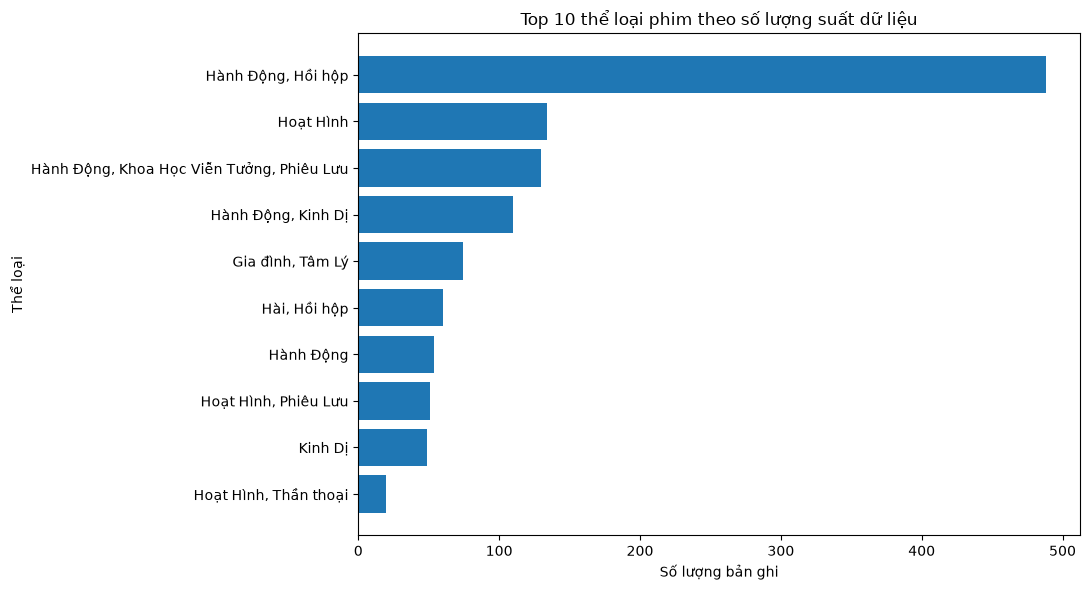

In [56]:
if 'Genre' in df.columns:
    counts = df['Genre'].astype(str).value_counts().head(10).sort_values()
    plt.figure(figsize=(11,6))
    plt.barh(counts.index, counts.values)
    plt.title('Top 10 thể loại phim theo số lượng suất dữ liệu')
    plt.xlabel('Số lượng bản ghi')
    plt.ylabel('Thể loại')
    plt.tight_layout()
    plt.show()
else:
    print('Không tìm thấy cột Genre.')


### 💡 So What?

Biểu đồ cho thấy dữ liệu có phân bố thể loại đồng đều hay tập trung vào một số nhóm. Nếu một vài thể loại chiếm phần lớn bản ghi, feature `Genre` có thể có phân bố mất cân bằng. Khi xây dựng mô hình AI, cần mã hóa biến phân loại phù hợp và kiểm tra số lượng mẫu của từng nhóm để tránh mô hình học quá nhiều từ các nhóm chiếm ưu thế.

## Biểu đồ 4 – Heatmap: Ma trận tương quan giữa các biến số

In [57]:
corr_cols_out = [c for c in ['Rating', 'DurationMinutes'] if c in df.columns]
# Bổ sung các cột số khác nếu dataset thực tế có
if len(numeric_cols) >= 2:
    corr_cols_out = numeric_cols

if len(corr_cols_out) >= 2:
    corr_out = df[corr_cols_out].corr(method='pearson')
    plt.figure(figsize=(9,7))
    plt.imshow(corr_out, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(label='Hệ số tương quan Pearson')
    plt.xticks(range(len(corr_out.columns)), corr_out.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_out.index)), corr_out.index)
    for i in range(len(corr_out.index)):
        for j in range(len(corr_out.columns)):
            plt.text(j, i, f'{corr_out.iloc[i,j]:.2f}', ha='center', va='center')
    plt.title('Ma trận tương quan giữa các biến số')
    plt.tight_layout()
    plt.show()
else:
    print('Chưa đủ ít nhất 2 biến số để tạo heatmap.')


ValueError: could not convert string to float: 'T13'

### 💡 So What?

Heatmap giúp nhận diện mức độ liên hệ tuyến tính giữa các biến số. Tương quan cao giữa hai feature có thể gợi ý thông tin trùng lặp, trong khi tương quan thấp cho thấy quan hệ tuyến tính yếu. Kết quả này hỗ trợ bước chọn feature cho mô hình AI, nhưng **không được hiểu là quan hệ nhân quả** và cũng không loại trừ các quan hệ phi tuyến.

## Biểu đồ 5 – Scatter plot: Thời lượng và Rating

In [ ]:
if 'DurationMinutes' in df.columns and 'Rating' in df.columns:
    plot_df = df[['DurationMinutes','Rating']].copy()
    plot_df['DurationMinutes'] = pd.to_numeric(plot_df['DurationMinutes'], errors='coerce')
    plot_df['Rating'] = pd.to_numeric(plot_df['Rating'], errors='coerce')
    plot_df = plot_df.dropna()
    plt.figure(figsize=(10,6))
    plt.scatter(plot_df['DurationMinutes'], plot_df['Rating'], alpha=0.55)
    plt.title('Mối quan hệ giữa thời lượng phim và Rating')
    plt.xlabel('Thời lượng (phút)')
    plt.ylabel('Rating')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('Thiếu DurationMinutes hoặc Rating.')


### 💡 So What?

Scatter plot cho phép quan sát trực tiếp xu hướng giữa `DurationMinutes` và `Rating`. Nếu các điểm không tạo thành xu hướng rõ ràng, thời lượng có thể không giải thích tốt Rating theo quan hệ tuyến tính. Nếu có xu hướng hoặc cụm điểm, `DurationMinutes` có thể cung cấp thông tin cho mô hình dự đoán. Các điểm nằm xa phần lớn dữ liệu cần được kiểm tra như những trường hợp bất thường trước khi huấn luyện.

## Biểu đồ 6 – Grouped Boxplot: Rating theo thể loại phim

In [ ]:
if 'Genre' in df.columns and 'Rating' in df.columns:
    temp = df[['Genre','Rating']].copy()
    temp['Rating'] = pd.to_numeric(temp['Rating'], errors='coerce')
    temp = temp.dropna()
    top_genres = temp['Genre'].astype(str).value_counts().head(8).index
    temp = temp[temp['Genre'].astype(str).isin(top_genres)].copy()
    groups = []
    labels = []
    for g in top_genres:
        vals = temp.loc[temp['Genre'].astype(str) == g, 'Rating'].dropna().values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(str(g))
    plt.figure(figsize=(13,7))
    plt.boxplot(groups, labels=labels)
    plt.title('Phân phối Rating theo Top 8 thể loại phim')
    plt.xlabel('Thể loại')
    plt.ylabel('Rating')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Thiếu Genre hoặc Rating.')


### 💡 So What?

Grouped boxplot cho phép so sánh median, độ phân tán và outlier của `Rating` giữa các thể loại. Nếu các nhóm có phân phối khác nhau đáng kể, `Genre` có thể chứa thông tin hữu ích cho bài toán dự đoán/phân loại liên quan đến Rating. Trước khi huấn luyện, cần kiểm tra kích thước từng nhóm và cân nhắc cách mã hóa categorical feature phù hợp.

# 12. CHECKLIST SẢN PHẨM ĐẦU RA

| Sản phẩm yêu cầu | Trạng thái trong notebook |
|---|---|
| Mã nguồn làm sạch & điền dữ liệu | ✅ Có quy trình kiểm tra missing, imputation và so sánh trước/sau |
| Master Dataset hoàn chỉnh | ✅ Có `df` sau xử lý và xuất `cgv_eda_cleaned.csv` |
| Tối thiểu 5 biểu đồ | ✅ Có 6 biểu đồ chuẩn đầu ra |
| Biểu đồ đơn biến | ✅ Histogram/KDE, Boxplot, Bar chart |
| Biểu đồ đa biến | ✅ Heatmap, Scatter plot, Grouped Boxplot |
| Tiêu đề + nhãn trục | ✅ Có trên từng biểu đồ chuẩn đầu ra |
| Insight "So What?" ngay dưới biểu đồ | ✅ Có Markdown Cell riêng sau từng biểu đồ |
| Định hướng lựa chọn mô hình AI | ✅ Mỗi Insight đều nêu tác động tới feature/model preparation |


## 13. Ghi chú khi nộp bài

Trước khi nộp, hãy **Run All** notebook từ đầu đến cuối để đảm bảo kết nối MongoDB Atlas thành công, dữ liệu được tải về, các bước làm sạch chạy đúng và 6 biểu đồ đều hiển thị. Không đưa password MongoDB trực tiếp vào notebook hoặc GitHub. Nếu dùng `MONGODB_URI`, nên nhập khi chạy notebook hoặc dùng biến môi trường.